# Comparaison de strategies multi-agents

Ce notebook permet de lancer plusieurs configurations de l'EDA multi-agent et de comparer :
- la fitness moyenne (`average_test_score`)
- la distance de Hamming moyenne entre agents
- la divergence de KL moyenne entre agents


In [51]:

from pathlib import Path
import sys
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

try:
    import pandas as pd
except ImportError:  # pragma: no cover - depend du setup local
    pd = None
    print("Pandas n'est pas installe : les tableaux seront affiches comme dictionnaires.")

try:
    from IPython.display import display
except ImportError:  # pragma: no cover
    display = print

plt.style.use('seaborn-v0_8')

def find_repo_root(start: Optional[Path] = None) -> Path:
    start_path = (start or Path.cwd()).resolve()
    for candidate in [start_path] + list(start_path.parents):
        if (candidate / 'source_code').exists():
            return candidate
    raise RuntimeError('Impossible de localiser la racine du depot.')

REPO_ROOT = find_repo_root()
SOURCE_DIR = REPO_ROOT / 'source_code'
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))
CONFIG_ROOT = REPO_ROOT / 'config'
AGENT_CFG_DIR = CONFIG_ROOT / 'agent'
PROBLEM_CFG_DIR = CONFIG_ROOT / 'problem'
KERNEL_CFG_DIR = CONFIG_ROOT / 'kernel'
MAIN_CFG_PATH = CONFIG_ROOT / 'config.yaml'

print(f'Repertoire racine: {REPO_ROOT}')
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch utilisera: {DEVICE}')


Repertoire racine: /home/landos/Documents/Supplementary-material
PyTorch utilisera: cuda:0


In [52]:

import os
from typing import Tuple

from eda_strategies.FactoryStrategyEA import FactoryStrategyEA
from environment.qubo import getTensorInstances_QUBO, get_Score_trajectoriesQUBO_cuda

import importlib
import eda_strategies.MultiAgentUnivariate.SVGD_EDA as ma_module
import eda_strategies.FactoryStrategyEA as factory_module
importlib.reload(ma_module)
importlib.reload(factory_module)
FactoryStrategyEA = factory_module.FactoryStrategyEA
factory = FactoryStrategyEA()

def load_problem_cfg(main_config_path: Path, problem_dir: Path) -> Dict[str, Any]:
    defaults: Dict[str, Any] = dict(
        type_problem='QUBO',
        dim=64,
        type_instance=0,
        nb_instances_test=10,
        nb_restarts=10,
        budget=50000,
        verbose=False,
    )
    cfg = defaults.copy()
    overrides: Dict[str, Any] = {}
    problem_name = None
    if main_config_path.exists():
        with main_config_path.open('r', encoding='utf-8') as fh:
            main_cfg = yaml.safe_load(fh) or {}
        defaults_list = main_cfg.get('defaults', [])
        for entry in defaults_list:
            if isinstance(entry, dict) and 'problem' in entry:
                problem_name = entry['problem']
                break
        overrides = {
            key: main_cfg[key]
            for key in ('nb_instances_test', 'nb_restarts', 'budget', 'verbose')
            if key in main_cfg
        }
    else:
        print(f"Avertissement: {main_config_path} introuvable. Utilisation des valeurs par defaut.")
    problem_key = (problem_name or cfg['type_problem']).lower()
    problem_cfg_path = problem_dir / f'{problem_key}.yaml'
    if problem_cfg_path.exists():
        with problem_cfg_path.open('r', encoding='utf-8') as fh:
            problem_cfg = yaml.safe_load(fh) or {}
        cfg.update(problem_cfg)
    else:
        print(f"Avertissement: {problem_cfg_path} introuvable. Utilisation des valeurs par defaut.")
    cfg.update(overrides)
    cfg['type_problem'] = str(cfg.get('type_problem', 'QUBO'))
    cfg['dim'] = int(cfg.get('dim', 64))
    cfg['type_instance'] = int(cfg.get('type_instance', 0))
    cfg['nb_instances_test'] = int(cfg.get('nb_instances_test', 10))
    cfg['nb_restarts'] = int(cfg.get('nb_restarts', 10))
    cfg['budget'] = int(cfg.get('budget', 10000))
    cfg['verbose'] = bool(cfg.get('verbose', False))
    cfg['seed'] = int(cfg.get('seed', 42))
    torch.manual_seed(cfg['seed'])
    np.random.seed(cfg['seed'])
    return cfg

def resolve_agent_cfg_path(main_config_path: Path, agent_dir: Path) -> Path:
    agent_name = None
    if main_config_path.exists():
        with main_config_path.open('r', encoding='utf-8') as fh:
            main_cfg = yaml.safe_load(fh) or {}
        for entry in main_cfg.get('defaults', []):
            if isinstance(entry, dict) and 'agent' in entry:
                agent_name = entry['agent']
                break
    else:
        print(f"Avertissement: {main_config_path} introuvable. Utilisation des valeurs par defaut.")
    agent_key = (agent_name or 'reinforce').lower()
    cfg_path = agent_dir / f'{agent_key}.yaml'
    if not cfg_path.exists():
        print(f"Avertissement: {cfg_path} introuvable. Utilisation de reinforce.yaml.")
        cfg_path = agent_dir / 'reinforce.yaml'
    return cfg_path

def load_base_agent_cfg(config_path: Path) -> Dict[str, Any]:
    defaults: Dict[str, Any] = dict(
        lambda_=20,
        M=4,
        learning_rate=0.0,
        epsilon_svgd=0.8,
        svgd_gamma=10.0,
        advantage='baseline',
        kernel='rbf',
    )
    cfg = defaults.copy()
    if config_path.exists():
        with config_path.open('r', encoding='utf-8') as fh:
            raw_cfg = yaml.safe_load(fh) or {}
        raw_cfg = raw_cfg.copy()
        if 'lambda' in raw_cfg and 'lambda_' not in raw_cfg:
            raw_cfg['lambda_'] = raw_cfg.pop('lambda')
        if 'gamma' in raw_cfg and 'svgd_gamma' not in raw_cfg:
            raw_cfg['svgd_gamma'] = raw_cfg.pop('gamma')
        cfg.update(raw_cfg)
    else:
        print(f"Avertissement: {config_path} introuvable. Utilisation des valeurs par defaut.")
    cfg['lambda_'] = int(cfg['lambda_'])
    cfg['M'] = int(cfg['M'])
    cfg['learning_rate'] = float(cfg.get('learning_rate', 0.0))
    cfg['epsilon_svgd'] = float(cfg.get('epsilon_svgd', 0.0))
    cfg['svgd_gamma'] = float(cfg.get('svgd_gamma', 10.0))
    cfg['advantage'] = cfg.get('advantage', 'baseline')
    cfg['kernel'] = str(cfg.get('kernel', 'rbf')).lower()
    return cfg

def load_kernel_cfg(kernel_name: Optional[str], kernel_dir: Path) -> Dict[str, Any]:
    name = str(kernel_name or 'rbf').lower()
    cfg_path = kernel_dir / f'{name}.yaml'
    kernel_cfg: Dict[str, Any] = {}
    if cfg_path.exists():
        with cfg_path.open('r', encoding='utf-8') as fh:
            kernel_cfg = yaml.safe_load(fh) or {}
    else:
        print(f"Avertissement: {cfg_path} introuvable. Utilisation de parametres par defaut pour le kernel {name}.")
    lr_svgd = float(kernel_cfg.get('epsilon_svgd', 0.0))
    gamma = float(kernel_cfg.get('gamma', 1.0))
    params = kernel_cfg.get('params') or {}
    return {'name': name, 'epsilon_svgd': lr_svgd, 'gamma': gamma, 'params': params}

def load_strategy_variants(main_config_path: Path) -> List[Dict[str, Any]]:
    defaults = [
        {'advantage': 'baseline', 'label': 'Baseline'},
        {'advantage': 'globalrankweighted', 'label': 'Global rank weighted'},
        {'advantage': 'peragentrankweighted', 'label': 'Per-agent rank weighted'},
    ]
    if not main_config_path.exists():
        print(f"Avertissement: {main_config_path} introuvable. Utilisation des strategies par defaut.")
        return defaults
    with main_config_path.open('r', encoding='utf-8') as fh:
        main_cfg = yaml.safe_load(fh) or {}
    entries = main_cfg.get('strategy_variants')
    if not isinstance(entries, list):
        return defaults
    variants: List[Dict[str, Any]] = []
    for entry in entries:
        if isinstance(entry, str):
            variants.append({'advantage': entry, 'label': entry})
        elif isinstance(entry, dict):
            adv = entry.get('advantage')
            if not adv:
                continue
            normalized = {'advantage': adv, 'label': entry.get('label', adv)}
            extra = {k: v for k, v in entry.items() if k not in {'advantage', 'label'}}
            normalized.update(extra)
            variants.append(normalized)
    return variants or defaults

DEFAULT_PROBLEM_CFG: Dict[str, Any] = load_problem_cfg(MAIN_CFG_PATH, PROBLEM_CFG_DIR)
AGENT_CFG_PATH = resolve_agent_cfg_path(MAIN_CFG_PATH, AGENT_CFG_DIR)
BASE_AGENT_CFG: Dict[str, Any] = load_base_agent_cfg(AGENT_CFG_PATH)
STRATEGY_VARIANTS: List[Dict[str, Any]] = load_strategy_variants(MAIN_CFG_PATH)


In [53]:

import random
from environment.nk import getTensorInstances_NK, get_Score_trajectoriesNK_cuda


def load_qubo_instances(problem_cfg: Dict[str, Any], *, device: str = 'cpu') -> Tuple[torch.Tensor, int]:
    """Charge les instances QUBO pour la configuration donnee.
    Retourne un tensor Q et la dimension effective utilisee (utile si fallback).
    """
    cfg = dict(problem_cfg or {})
    dim = int(cfg.get('dim', 64))
    type_instance = int(cfg.get('type_instance', 0))
    nb_instances = int(cfg.get('nb_instances_test', 1))
    nb_restarts = int(cfg.get('nb_restarts', 1))
    phase = str(cfg.get('phase', 'test'))
    instances_dir = SOURCE_DIR / 'instances' / 'QUBO'
    if not instances_dir.exists():
        raise FileNotFoundError(f"Dossier d'instances QUBO introuvable: {instances_dir}")
    instance_path = str(instances_dir) + os.sep

    def _available_dims_for_type(target_type: int):
        dims = set()
        pattern = 'puboi_evo_n_*_t_*_i_*.json'
        for fpath in instances_dir.glob(pattern):
            stem = fpath.stem.split('_')
            try:
                idx_n = stem.index('n')
                idx_t = stem.index('t')
                dim_val = int(stem[idx_n + 1])
                type_val = int(stem[idx_t + 1])
            except (ValueError, IndexError):
                continue
            if type_val == target_type:
                dims.add(dim_val)
        return sorted(dims)

    try:
        tensor_Q = getTensorInstances_QUBO(
            instance_path,
            nb_instances,
            nb_restarts,
            dim,
            type_instance,
            device,
            phase,
        )
        actual_dim = dim
    except FileNotFoundError:
        candidates = _available_dims_for_type(type_instance)
        if not candidates:
            raise
        # choose the closest available dimension to the requested one
        fallback_dim = min(candidates, key=lambda value: (abs(value - dim), value))
        if fallback_dim == dim:
            raise
        print(
            f"Instances QUBO dim={dim} introuvables pour type_instance={type_instance}; "
            f"utilisation de dim={fallback_dim}."
        )
        tensor_Q = getTensorInstances_QUBO(
            instance_path,
            nb_instances,
            nb_restarts,
            fallback_dim,
            type_instance,
            device,
            phase,
        )
        actual_dim = fallback_dim

    return tensor_Q, actual_dim

def summarize_run(label, cfg, scores, history):
    history = history or {}
    cfg = cfg or {}
    scores = np.asarray(scores) if scores is not None else np.asarray([])
    hamming_history = history.get('avg_hamming', [])
    js_history = history.get('avg_js', [])
    l2_history = history.get('avg_l2', [])
    entropy_history = history.get('avg_entropy', [])
    best_fitness_history = history.get('best_fitness', [])
    best_fitness_history = [-x for x in best_fitness_history]

    def _final(values):
        return float(values[-1]) if values else float('nan')

    def _mean(values):
        values = np.asarray(values)
        return float(np.mean(values)) if values.size else float('nan')

    summary = {
        'label': label,
        'config': cfg,
        'average_test_score': _mean(scores),
        'best_average_fitness': float(best_fitness_history[-1]) if best_fitness_history else float('nan'),
        'final_hamming': _final(hamming_history),
        'mean_hamming': _mean(hamming_history),
        'final_js': _final(js_history),
        'mean_js': _mean(js_history),
        'final_l2': _final(l2_history),
        'mean_l2': _mean(l2_history),
        'final_entropy': _final(entropy_history),
        'mean_entropy': _mean(entropy_history),
        'runtime': history.get('runtime', []),
        'hamming_history': hamming_history,
        'js_history': js_history,
        'l2_history': l2_history,
        'entropy_history': entropy_history,
        'best_fitness_history': best_fitness_history,
    }
    return summary


def _normalize_agent_cfg(raw_cfg: Dict[str, Any]) -> Dict[str, Any]:
    cfg = dict(raw_cfg or {})
    if 'lambda' in cfg and 'lambda_' not in cfg:
        cfg['lambda_'] = cfg.pop('lambda')
    if 'gamma' in cfg and 'svgd_gamma' not in cfg:
        cfg['svgd_gamma'] = cfg.pop('gamma')
    cfg['lambda_'] = int(cfg.get('lambda_', 1))
    cfg['M'] = int(cfg.get('M', 1))
    cfg['learning_rate'] = float(cfg.get('learning_rate', 0.0))
    cfg['epsilon_svgd'] = float(cfg.get('epsilon_svgd', 0.0))
    cfg['svgd_gamma'] = float(cfg.get('svgd_gamma', 10.0))
    cfg['advantage'] = cfg.get('advantage', 'baseline')
    cfg['kernel'] = str(cfg.get('kernel', 'rbf')).lower()
    cfg.pop('kernel_config', None)
    return cfg


def _apply_kernel_settings(agent_cfg: Dict[str, Any]) -> Dict[str, Any]:
    cfg = dict(agent_cfg or {})
    kernel_info = load_kernel_cfg(cfg.get('kernel'), KERNEL_CFG_DIR)
    cfg['kernel'] = kernel_info['name']
    cfg['epsilon_svgd'] = float(kernel_info.get('epsilon_svgd', cfg.get('epsilon_svgd', 0.0)))
    cfg['svgd_gamma'] = float(kernel_info.get('gamma', cfg.get('svgd_gamma', 10.0)))
    cfg['kernel_config'] = {
        'name': kernel_info['name'],
        'params': kernel_info.get('params') or {},
    }
    return cfg


def _merge_agent_cfg(base_cfg: Dict[str, Any], overrides: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
    merged = dict(base_cfg or {})
    if overrides:
        merged.update(overrides)
    merged = _normalize_agent_cfg(merged)
    return _apply_kernel_settings(merged)


def _build_strategy(dim: int, type_problem: str, agent_cfg: Dict[str, Any], *, enable_visualization: bool) -> Any:
    dim_variables = [3 for _ in range(dim)] if type_problem == 'NK3' else None
    return factory.createStrategyEA(
        'PPO-EDA',
        dim,
        agent_cfg['lambda_'],
        DEVICE,
        dim_variables,
        agent_cfg['M'],
        learning_rate=agent_cfg.get('learning_rate', 0.0),
        epsilon_svgd=agent_cfg['epsilon_svgd'],
        enable_visualization=enable_visualization,
        svgd_gamma=agent_cfg['svgd_gamma'],
        advantage_cfg=agent_cfg.get('advantage'),
        kernel_config=agent_cfg.get('kernel_config'),
    ).to(DEVICE)


def run_strategy(strategy_cfg: Dict[str, Any], *, problem_cfg: Optional[Dict[str, Any]] = None,
                 base_agent_cfg: Optional[Dict[str, Any]] = None, enable_visualization: bool = False) -> Dict[str, Any]:
    if not isinstance(strategy_cfg, dict):
        raise ValueError('Chaque strategie doit etre un dictionnaire de parametres.')
    label = strategy_cfg.get('label') or strategy_cfg.get('advantage') or 'Strategy'

    variant = {k: v for k, v in strategy_cfg.items() if k != 'label'}
    merged_agent_cfg = _merge_agent_cfg(base_agent_cfg or BASE_AGENT_CFG, variant)

    effective_problem_cfg = dict(problem_cfg or DEFAULT_PROBLEM_CFG)
    type_problem = str(effective_problem_cfg.get('type_problem', 'QUBO')).upper()
    effective_problem_cfg['type_problem'] = type_problem

    nb_instances = int(effective_problem_cfg.get('nb_instances_test', 1))
    nb_restarts = int(effective_problem_cfg.get('nb_restarts', 1))
    budget = int(effective_problem_cfg.get('budget', 10000))
    verbose = bool(effective_problem_cfg.get('verbose', False))
    seed = int(effective_problem_cfg.get('seed', DEFAULT_PROBLEM_CFG.get('seed', 0)))

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    lambda_ = merged_agent_cfg['lambda_']
    dim = int(effective_problem_cfg.get('dim', 64))
    type_instance = int(effective_problem_cfg.get('type_instance', 0))

    history = {}
    scores = []
    lambda_advantages = None
    lambda_scores = None
    lambda_advantages_all = None
    lambda_scores_all = None

    if type_problem == 'QUBO':
        tensor_Q, actual_dim = load_qubo_instances(effective_problem_cfg, device=DEVICE)
        effective_problem_cfg['dim'] = actual_dim
        strategy = _build_strategy(actual_dim, type_problem, merged_agent_cfg, enable_visualization=enable_visualization)
        scores, history = get_Score_trajectoriesQUBO_cuda(
            strategy,
            actual_dim,
            nb_instances,
            nb_restarts,
            budget,
            lambda_,
            tensor_Q,
            DEVICE,
            verbose,
            enable_visualization=enable_visualization,
            return_history=True,
        )
    elif type_problem in {'NK', 'NK3'}:
        D = 3 if type_problem == 'NK3' else 2
        nk_root = SOURCE_DIR / 'instances' / ('nk3' if type_problem == 'NK3' else 'nk') / str(dim) / str(type_instance)
        nk_path = str(nk_root) + os.sep
        tensor_matrix_locus, tensor_matrix_contrib, _ = getTensorInstances_NK(
            nk_path,
            nb_instances,
            nb_restarts,
            lambda_,
            dim,
            D,
            type_instance,
            DEVICE,
        )
        vector_index = np.zeros((type_instance + 1), dtype=np.float32)
        for idx in range(type_instance + 1):
            vector_index[idx] = D ** (type_instance - idx)
        vector_index_th = torch.tensor(vector_index, dtype=torch.float32).to(DEVICE)
        strategy = _build_strategy(dim, type_problem, merged_agent_cfg, enable_visualization=enable_visualization)
        scores, history = get_Score_trajectoriesNK_cuda(
            strategy,
            dim,
            type_instance,
            D,
            nb_instances,
            nb_restarts,
            budget,
            lambda_,
            vector_index_th,
            tensor_matrix_locus,
            tensor_matrix_contrib,
            DEVICE,
            verbose,
            None,
            enable_visualization=enable_visualization,
            return_history=True,
        )
    else:
        raise ValueError(f"Type de probleme non supporte: {type_problem}")

    get_advantages = getattr(strategy, 'get_latest_advantages', None)
    get_scores = getattr(strategy, 'get_latest_scores', None)
    if callable(get_scores):
        score_tensor = get_scores()
        if score_tensor is not None:
            score_data = score_tensor.tolist()
            if score_data and isinstance(score_data[0], list):
                lambda_scores = score_data[0]
            else:
                lambda_scores = score_data
            lambda_scores_all = score_data

    if callable(get_advantages):
        adv_tensor = get_advantages()
        if adv_tensor is not None:
            adv_data = adv_tensor.tolist()
            if adv_data and isinstance(adv_data[0], list):
                lambda_advantages = adv_data[0]
            else:
                lambda_advantages = adv_data
            lambda_advantages_all = adv_data

    run_cfg = {
        'problem': dict(effective_problem_cfg),
        'agent': dict(merged_agent_cfg),
    }
    summary = summarize_run(label, run_cfg, scores, history)
    summary['lambda_advantages'] = lambda_advantages
    summary['lambda_scores'] = lambda_scores
    summary['lambda_advantages_all'] = lambda_advantages_all
    summary['lambda_scores_all'] = lambda_scores_all
    return summary


In [54]:

strategy_variants = STRATEGY_VARIANTS

strategies: List[Dict[str, Any]] = []
for variant in strategy_variants:
    if not isinstance(variant, dict):
        continue
    variant = variant.copy()
    advantage_name = variant.pop('advantage', None)
    if advantage_name is None:
        continue
    label_prefix = variant.pop('label', advantage_name)
    append_params = bool(variant.pop('append_params', True))
    overrides = {k: v for k, v in variant.items()}
    norm_overrides = overrides.copy()
    if 'lambda' in norm_overrides and 'lambda_' not in norm_overrides:
        norm_overrides['lambda_'] = norm_overrides.pop('lambda')
    if 'gamma' in norm_overrides and 'svgd_gamma' not in norm_overrides:
        norm_overrides['svgd_gamma'] = norm_overrides.pop('gamma')
    preview_overrides = norm_overrides.copy()
    preview_overrides['advantage'] = advantage_name
    preview_cfg = _merge_agent_cfg(BASE_AGENT_CFG, preview_overrides)
    if append_params:
        label = (
            f"{label_prefix} (kernel={preview_cfg['kernel']}, M={preview_cfg['M']}, "
            f"lambda={preview_cfg['lambda_']}, lr_svgd={preview_cfg['epsilon_svgd']}, "
            f"gamma={preview_cfg['svgd_gamma']})"
        )
    else:
        label = label_prefix
    strategy_entry = {'label': label, 'advantage': advantage_name}
    strategy_entry.update(norm_overrides)
    strategies.append(strategy_entry)

allowed_advantages = {'globalrankweighted', 'normalizedfitness'}
strategies = [s for s in strategies if str(s.get('advantage', '')).lower() in allowed_advantages]

strategies


[{'label': 'Global rank weighted (kernel=rbf, M=5, lambda=6, lr_svgd=0.015, gamma=0.005)',
  'advantage': 'globalrankweighted'},
 {'label': 'Normalized fitness (kernel=rbf, M=5, lambda=6, lr_svgd=0.015, gamma=0.005)',
  'advantage': 'normalizedfitness'}]

In [55]:
results: List[Dict[str, Any]] = []
for strat in strategies:
    print(f"[RUN] {strat.get('label', strat)}")
    summary = run_strategy(strat)
    results.append(summary)
print('Comparaison terminee.')

rows = [
    {
        'label': r['label'],
        'advantage': r['config'].get('advantage'),
        'best_avg_fitness': r['best_average_fitness'],
        'avg_test_score': r['average_test_score'],
        'final_hamming': r['final_hamming'],
        'final_js': r['final_js'],
        'final_l2': r['final_l2'],
        'final_entropy': r['final_entropy'],
        'mean_hamming': r['mean_hamming'],
        'mean_js': r['mean_js'],
        'mean_l2': r['mean_l2'],
        'mean_entropy': r['mean_entropy'],
    }
    for r in results
]

if pd is not None and rows:
    display(pd.DataFrame(rows))


[RUN] Global rank weighted (kernel=rbf, M=5, lambda=6, lr_svgd=0.015, gamma=0.005)


100%|██████████| 333/333 [00:01<00:00, 222.61it/s, avg_hamming=12.9, avg_js=None, bestScore=-201, current_score=-199, leader=0] 


[RUN] Normalized fitness (kernel=rbf, M=5, lambda=6, lr_svgd=0.015, gamma=0.005)


100%|██████████| 333/333 [00:01<00:00, 230.02it/s, avg_hamming=11.9, avg_js=None, bestScore=-200, current_score=-198, leader=0] 

Comparaison terminee.


,label,advantage,best_avg_fitness,avg_test_score,final_hamming,final_js,final_l2,final_entropy,mean_hamming,mean_js,mean_l2,mean_entropy
0,"Global rank weighted (kernel=rbf, M=5, lambda=...",None,201.080002,-201.080002,12.874677,0.0,0.0,6.626140,21.068631,0.0,0.0,24.979228
1,"Normalized fitness (kernel=rbf, M=5, lambda=6,...",None,200.339996,-200.339996,11.944728,0.0,0.0,7.208745,23.560987,0.0,0.0,30.522309


In [56]:
def summarize_run(label, cfg, scores, history):
    history = history or {}
    cfg = cfg or {}
    scores = np.asarray(scores) if scores is not None else np.asarray([])
    hamming_history = history.get('avg_hamming', [])
    js_history = history.get('avg_js', [])
    l2_history = history.get('avg_l2', [])
    entropy_history = history.get('avg_entropy', [])
    best_fitness_history = history.get('best_fitness', [])
    best_fitness_history = [-x for x in best_fitness_history]

    def _final(values):
        return float(values[-1]) if values else float('nan')

    def _mean(values):
        return float(np.mean(values)) if values else float('nan')

    summary = {
        'label': label,
        'config': cfg,
        'average_test_score': float(np.mean(scores)) if scores.size else float('nan'),
        'best_average_fitness': float(best_fitness_history[-1]) if best_fitness_history else float('nan'),
        'final_hamming': _final(hamming_history),
        'mean_hamming': _mean(hamming_history),
        'final_js': _final(js_history),
        'mean_js': _mean(js_history),
        'final_l2': _final(l2_history),
        'mean_l2': _mean(l2_history),
        'final_entropy': _final(entropy_history),
        'mean_entropy': _mean(entropy_history),
        'runtime': history.get('runtime', []),
        'hamming_history': hamming_history,
        'js_history': js_history,
        'l2_history': l2_history,
        'entropy_history': entropy_history,
        'best_fitness_history': best_fitness_history,
    }
    return summary


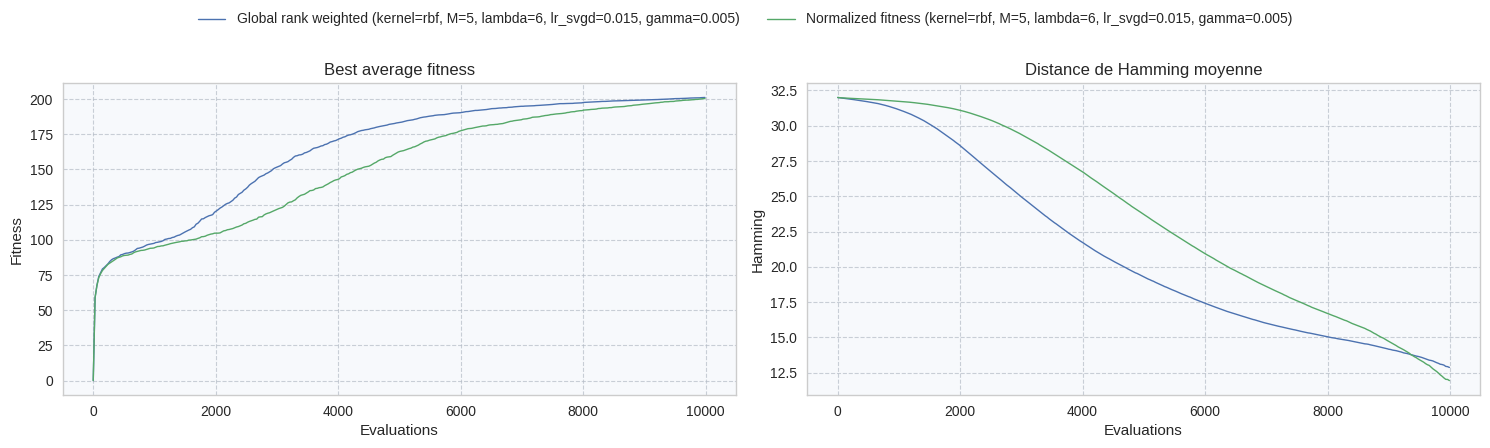

In [57]:
if results:
    import math
    metrics = [
        ('best_fitness_history', 'Best average fitness', 'Fitness'),
        ('hamming_history', 'Distance de Hamming moyenne', 'Hamming'),
    ]
    ncols = 2
    nrows = math.ceil(len(metrics) / ncols)
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.5 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)
    fig.subplots_adjust(top=0.88, hspace=0.4)
    line_kwargs = dict(linewidth=1.0)
    grid_kwargs = dict(color='#b5bcc7', linestyle='--', linewidth=0.8, alpha=0.7)
    bg_color = '#f7f9fc'

    for ax in axes:
        ax.set_facecolor(bg_color)
        ax.set_axisbelow(True)
        ax.grid(True, **grid_kwargs)

    def _baseline_value(result, key):
        if key == 'best_fitness_history':
            return 0.0
        if key == 'hamming_history':
            problem_cfg = (result.get('config') or {}).get('problem') or {}
            dim = problem_cfg.get('dim')
            try:
                dim_val = float(dim)
            except (TypeError, ValueError):
                return None
            return dim_val / 2.0
        return None

    def _plot_history(ax, key, title, ylabel):
        for result in results:
            history = result.get(key) or []
            if not history:
                continue
            runtime = result.get('runtime') or []
            steps = runtime[:len(history)] if runtime else list(range(1, len(history) + 1))
            baseline = _baseline_value(result, key)
            plot_values = list(history)
            plot_steps = list(steps)
            if baseline is not None:
                plot_values = [baseline] + plot_values
                plot_steps = [0] + plot_steps
            ax.plot(plot_steps, plot_values, label=result['label'], **line_kwargs)
        ax.set_title(title)
        ax.set_xlabel('Evaluations')
        ax.set_ylabel(ylabel)

    for idx, (key, title, ylabel) in enumerate(metrics):
        ax = axes[idx]
        _plot_history(ax, key, title, ylabel)

    for ax in axes[len(metrics):]:
        ax.set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=min(len(handles), 3))

    fig.tight_layout(rect=(0, 0, 1, 0.9))
else:
    print('Aucun resultat a tracer pour le moment.')


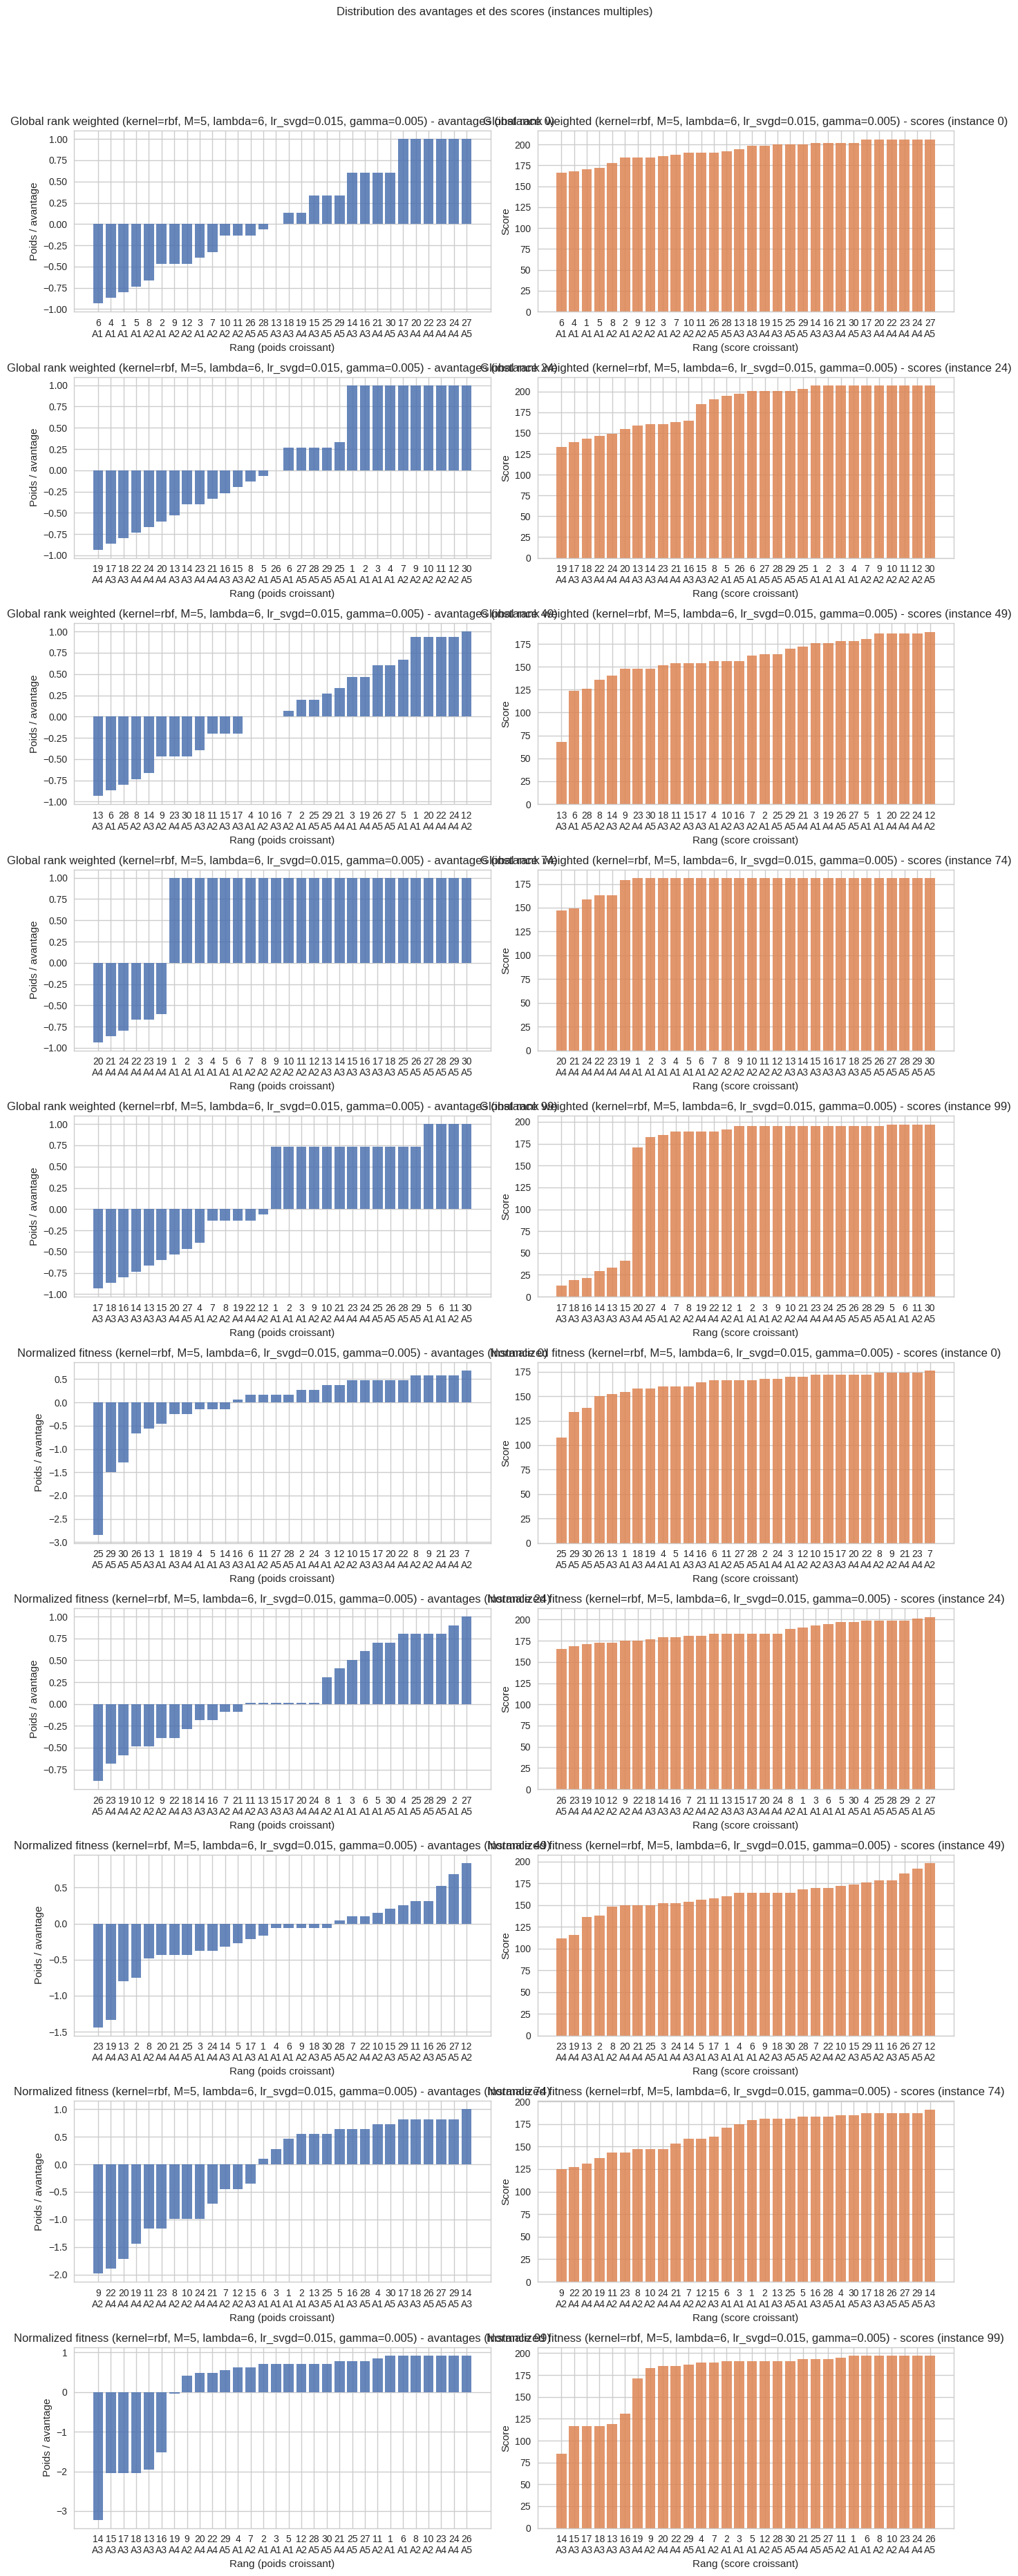

In [58]:
if results:
    valid_profiles = [
        (
            r['label'],
            r.get('lambda_advantages_all') or r.get('lambda_advantages'),
            r.get('lambda_scores_all') or r.get('lambda_scores'),
            r.get('config'),
        )
        for r in results
    ]
    valid_profiles = [
        (label, weights, scores, cfg)
        for label, weights, scores, cfg in valid_profiles
        if weights
    ]
    if not valid_profiles:
        print("Aucune mesure d'avantage disponible pour tracer les histogrammes.")
    else:
        max_instances_to_plot = 5

        def _agent_labels(cfg, lam_labels):
            agent_cfg = (cfg or {}).get('agent') or {}
            lambda_per_agent = int(agent_cfg.get('lambda_', 1) or 1)
            num_agents = int(agent_cfg.get('M', 1) or 1)
            agent_labels = []
            for idx in lam_labels:
                if lambda_per_agent > 0:
                    agent_id = (idx - 1) // lambda_per_agent + 1
                else:
                    agent_id = 1
                if num_agents > 0 and agent_id > num_agents:
                    agent_id = num_agents
                agent_labels.append(f'A{agent_id}')
            return agent_labels

        def _as_instances(values):
            arr = np.asarray(values, dtype=float)
            if arr.ndim == 1:
                return [arr.tolist()]
            return [row.tolist() for row in arr]

        def _pick_indices(count, max_count):
            if count <= max_count:
                return list(range(count))
            return np.linspace(0, count - 1, max_count, dtype=int).tolist()

        prepared = []
        for label, weights, scores, cfg in valid_profiles:
            weights_instances = _as_instances(weights)
            scores_instances = _as_instances(scores) if scores is not None else None
            inst_indices = _pick_indices(len(weights_instances), max_instances_to_plot)
            prepared.append((label, weights_instances, scores_instances, cfg, inst_indices))

        nrows = sum(len(p[4]) for p in prepared)
        ncols = 2
        fig, axes = plt.subplots(nrows, ncols, figsize=(6.8 * ncols, 3.8 * nrows))
        axes = np.array(axes).reshape(nrows, ncols)

        row = 0
        for label, weights_instances, scores_instances, cfg, inst_indices in prepared:
            for inst_idx in inst_indices:
                ax_adv = axes[row, 0]
                ax_score = axes[row, 1]

                weights = weights_instances[inst_idx]
                ordered_pairs = sorted(enumerate(weights, start=1), key=lambda pair: pair[1])
                lam_labels = [idx for idx, _ in ordered_pairs]
                sorted_weights = [w for _, w in ordered_pairs]
                positions = np.arange(1, len(sorted_weights) + 1)
                agent_labels = _agent_labels(cfg, lam_labels)

                ax_adv.bar(positions, sorted_weights, color='#4c72b0', alpha=0.85)
                ax_adv.set_title(f"{label} - avantages (instance {inst_idx})")
                ax_adv.set_xlabel('Rang (poids croissant)')
                ax_adv.set_ylabel('Poids / avantage')
                ax_adv.set_xticks(positions)
                ax_adv.set_xticklabels([f"{lam}\n{agent}" for lam, agent in zip(lam_labels, agent_labels)], rotation=0, ha='center')

                if scores_instances is not None and inst_idx < len(scores_instances):
                    scores = scores_instances[inst_idx]
                    ordered_scores = sorted(enumerate(scores, start=1), key=lambda pair: pair[1])
                    score_labels = [idx for idx, _ in ordered_scores]
                    sorted_scores = [s for _, s in ordered_scores]
                    score_positions = np.arange(1, len(sorted_scores) + 1)
                    score_agent_labels = _agent_labels(cfg, score_labels)

                    ax_score.bar(score_positions, sorted_scores, color='#dd8452', alpha=0.85)
                    ax_score.set_title(f"{label} - scores (instance {inst_idx})")
                    ax_score.set_xlabel('Rang (score croissant)')
                    ax_score.set_ylabel('Score')
                    ax_score.set_xticks(score_positions)
                    ax_score.set_xticklabels([f"{lam}\n{agent}" for lam, agent in zip(score_labels, score_agent_labels)], rotation=0, ha='center')
                else:
                    ax_score.text(0.5, 0.5, 'Scores indisponibles', ha='center', va='center')
                    ax_score.set_axis_off()

                row += 1

        fig.suptitle('Distribution des avantages et des scores (instances multiples)')
        fig.tight_layout(rect=(0, 0, 1, 0.95))
else:
    print('Aucun resultat disponible pour les histogrammes.')
